In [1]:
#library import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import joblib


In [2]:

#load dataset

df=pd.read_csv("diabetes.csv")
print(df.head())

cols=["Glucose","BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())
    

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  



Accuracy: 0.7395833333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.81      0.80       123
           1       0.65      0.61      0.63        69

    accuracy                           0.74       192
   macro avg       0.72      0.71      0.71       192
weighted avg       0.74      0.74      0.74       192



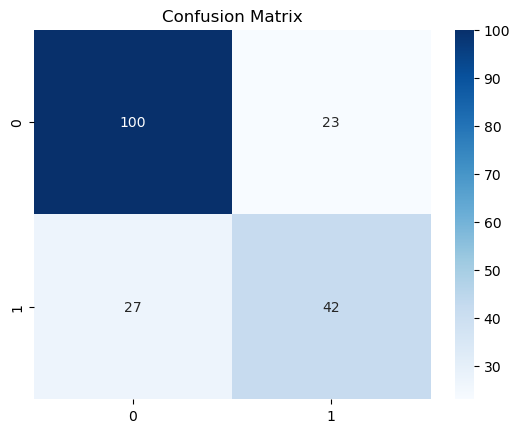

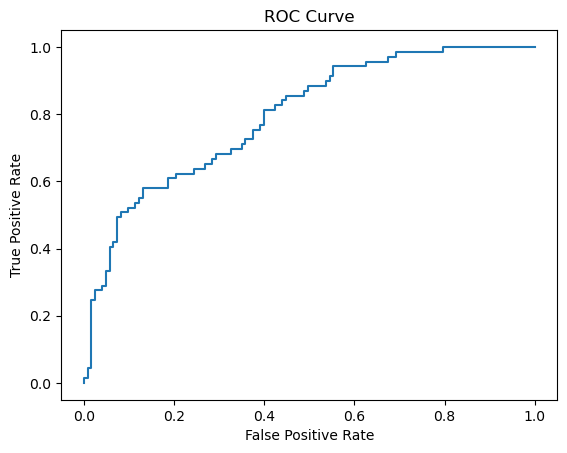

AUC Score:  0.7946270767055498

Model and scaler saved successfully as 'diabetes_model.pkl' and 'scaler.pkl'!


In [3]:
#Train-Test Split
X = df.drop("Outcome",axis = 1)
y = df["Outcome"]

X_train, X_test, y_train , y_test = train_test_split(
    X,y, test_size = 0.25 , random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
print("\nAccuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

#ROC Curve
y_prob = model.predict_proba(X_test)[:,1]
fpr,tpr,_=roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score: ", roc_auc_score(y_test , y_prob))

#7. Save Model & Scaler for Streamlit App
joblib.dump(model, "diabetes_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\nModel and scaler saved successfully as 'diabetes_model.pkl' and 'scaler.pkl'!")

In [4]:
%%writefile diabetes_app.py
import streamlit as st
import numpy as np
import joblib
try:
    model = joblib.load('diabetes_model.pkl')
    scaler = joblib.load('scaler.pkl')
except FileNotFoundError:
    st.error("Error: 'diabetes_model.joblib' or 'scaler.joblib' not found. Please ensure they are in the same directory as this script.")

#page configuration
st.set_page_config(
    page_title="Dια Sҽɳʂҽ- Smart Risk Analyzer",
    page_icon="🩺",
    layout="centered",
    initial_sidebar_state="expanded"
)

#Custom CSS Styling
st.markdown("""
    <style>
        .title {
            text-align: center;
            font-size: 38px;
            color: #B77B87;
            font-weight: 800;
            margin-bottom: 5px;
        }

        .title {
            text-align: center;
            font-size: 38px;
            color: #B77B87;
            margin-bottom: 20px;
        }

        .subtitle {
            text-align: center;
            color: #6F6875;
            font-size: 18px;
            margin-bottom: 20px;
        }

        .stButton>button {
            width: 100%;
            background-color: #D9A6AD;
            color: #4B4B4B;
            font-size: 18px;
            font-weight: 600;
            padding: 10px;
            border-radius: 15px;
            border: 1px solid #C9DCC5;
        }

        .stButton>button:hover {
            background-color: #C48F99;
            color: white;
        }

        .card {
            background-color: #FFFDF7;
            box-shadow: 1px 1px 10px #E6DDE0;
            padding: 14px;
            border-radius: 15px;
            border: 1px solid #EADCC8;
        }

        .footer{
            text-align : center;
            color: #6F6875;
            font-size: 14px;
            margin-top: 25px;
        }

    </style>
""",unsafe_allow_html=True)

#App header
st.markdown('<div class="title"> DiaSense</div>',unsafe_allow_html=True)
st.markdown('<div class="subtitle"> Smart Diabetes Risk Analyzer</div>',unsafe_allow_html=True)


#input section
st.markdown('<div class="card">', unsafe_allow_html=True)
col1, col2 = st.columns(2)
with col1:
    preg=st.number_input("Pregnancies", 0,20, step=1)
    bp=st.number_input("Blood Pressure", 0,200)
    insulin=st.number_input("Insulin", 0,900)
    dpf=st.number_input("Diabetes Pedigree Function", 0.0,3.0)
with col2:
    glucose=st.number_input("Glucose", 0,200)
    skin=st.number_input("Skin Thickness", 0,100)
    bmi=st.number_input("BMI", 0.0,70.0)
    age=st.number_input("Age", 0,120)
st.markdown('</div>', unsafe_allow_html=True)

#prediction button

st.write("")
predict_btn= st.button("Predict Diabetes Risk")
if predict_btn:
    input_data= np.array([[preg, glucose, bp, skin, insulin, bmi, dpf, age]])
    input_data= scaler.transform(input_data)
    pred= model.predict(input_data)[0]
    prob= model.predict_proba(input_data)[0][1]
    if pred==1:
        st.error(f"⚠️ HIGH RISK: The patient is *likely diabetic*\n\n **Probability:** {prob:.2f}")
    else:
        st.success(f" ✔️Low Risk: The patient is *not diabetic* \n\n **Probability:** {prob:.2f}")

#Footer with copyright
st.write("---")
st.markdown(
    "<p class='footer'? ©️ DiaSense- All Rights Reserved. </p>",unsafe_allow_html=True
)



Overwriting diabetes_app.py


In [ ]:
!streamlit run diabetes_app.py